In [1]:
# react the data 
import pandas as pd
raw = pd.read_csv('http://hilpisch.com/pyalgo_eikon_eod_data.csv', index_col=0, parse_dates=True).dropna()
data=pd.DataFrame(raw['XAU='])

In [2]:
import numpy as np
data.rename(columns={'XAU=' : 'price'}, inplace=True)

In [3]:
data['returns'] = np.log(data['price'] / data['price'].shift(1))

In [4]:
data['position'] = np.sign(data['returns'])

In [5]:
data['strategy'] = data['position'].shift(1) * data['returns']

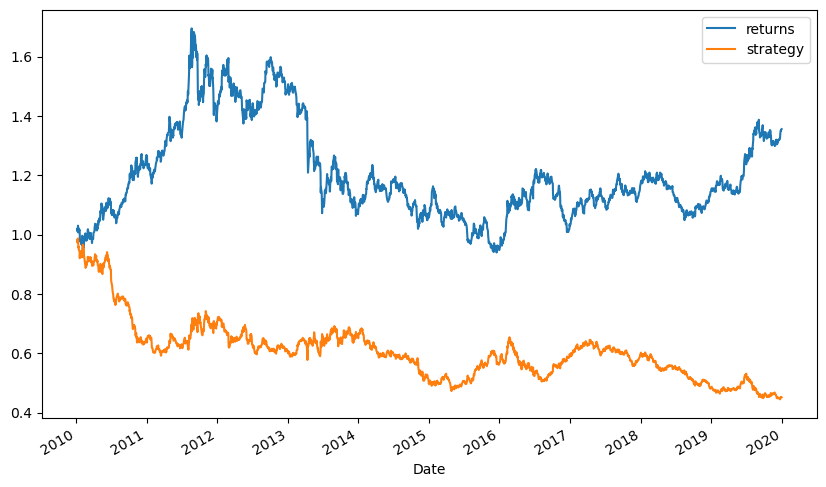

In [6]:
data[['returns', 'strategy']].dropna().cumsum().apply(np.exp).plot(figsize=(10, 6));

In [7]:
data['position'] = np.sign(data['returns'].rolling(3).mean())

In [8]:
data['strategy'] = data['position'].shift(1) * data['returns']

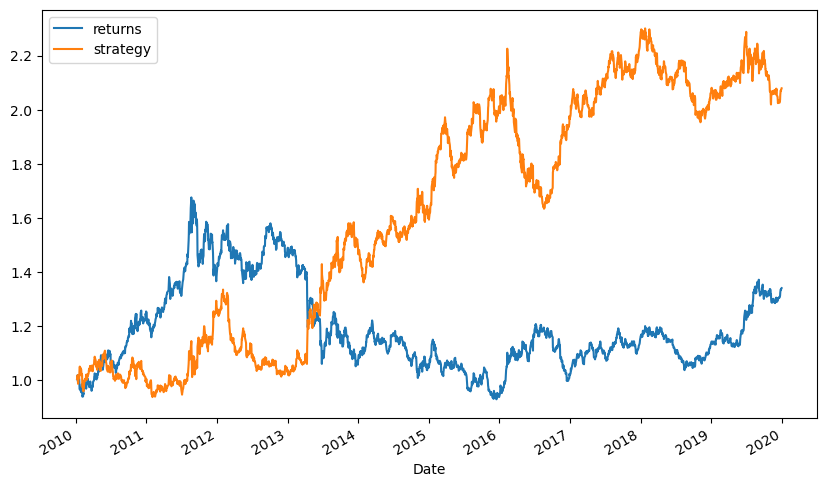

In [9]:
data[['returns', 'strategy']].dropna().cumsum().apply(np.exp).plot(figsize=(10, 6));

In [10]:
from dotenv import load_dotenv

load_dotenv()

True

In [14]:
import os

from datetime import datetime
from zoneinfo import ZoneInfo

from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
from typing import cast
from alpaca.data.models import BarSet

API_KEY=os.getenv("ALPACA_PAPER_API_KEY")
API_SECRET=os.getenv("ALPACA_PAPER_SECRET")

client = StockHistoricalDataClient(API_KEY, API_SECRET)
# Pick any past trading day.
# These times are in New York market time, then sent as timezone-aware datetimes.
start = datetime(2025, 3, 3, 9, 30, tzinfo=ZoneInfo("America/New_York"))
end   = datetime(2025, 3, 3, 16, 0, tzinfo=ZoneInfo("America/New_York"))

request = StockBarsRequest(
    symbol_or_symbols="AAPL",
    timeframe=cast(TimeFrame, TimeFrame.Minute),
    start=start,
    end=end
)

bars = cast(BarSet, client.get_stock_bars(request))
df = bars.df
print(df.head(10))
print()
print(df.tail(10))



                                      open      high       low     close  \
symbol timestamp                                                           
AAPL   2025-03-03 14:30:00+00:00  241.8100  242.3299  241.2100  241.7050   
       2025-03-03 14:31:00+00:00  241.7000  241.9900  241.0200  241.6850   
       2025-03-03 14:32:00+00:00  241.6850  242.7900  241.5800  242.7450   
       2025-03-03 14:33:00+00:00  242.7200  243.5900  242.7200  243.2500   
       2025-03-03 14:34:00+00:00  243.2500  243.4800  242.9600  243.2300   
       2025-03-03 14:35:00+00:00  243.2500  243.7500  243.2300  243.6100   
       2025-03-03 14:36:00+00:00  243.6261  243.8600  243.1700  243.7763   
       2025-03-03 14:37:00+00:00  243.7850  244.0272  243.1900  243.3900   
       2025-03-03 14:38:00+00:00  243.3800  243.6900  242.7151  243.0900   
       2025-03-03 14:39:00+00:00  243.0650  243.2300  242.7200  242.8800   

                                    volume  trade_count        vwap  
symbol timestamp 

In [15]:
df.info()

<class 'pandas.DataFrame'>
MultiIndex: 391 entries, ('AAPL', Timestamp('2025-03-03 14:30:00+0000', tz='UTC')) to ('AAPL', Timestamp('2025-03-03 21:00:00+0000', tz='UTC'))
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   open         391 non-null    float64
 1   high         391 non-null    float64
 2   low          391 non-null    float64
 3   close        391 non-null    float64
 4   volume       391 non-null    float64
 5   trade_count  391 non-null    float64
 6   vwap         391 non-null    float64
dtypes: float64(7)
memory usage: 25.7+ KB


In [16]:
print(df.index)

MultiIndex([('AAPL', '2025-03-03 14:30:00+00:00'),
            ('AAPL', '2025-03-03 14:31:00+00:00'),
            ('AAPL', '2025-03-03 14:32:00+00:00'),
            ('AAPL', '2025-03-03 14:33:00+00:00'),
            ('AAPL', '2025-03-03 14:34:00+00:00'),
            ('AAPL', '2025-03-03 14:35:00+00:00'),
            ('AAPL', '2025-03-03 14:36:00+00:00'),
            ('AAPL', '2025-03-03 14:37:00+00:00'),
            ('AAPL', '2025-03-03 14:38:00+00:00'),
            ('AAPL', '2025-03-03 14:39:00+00:00'),
            ...
            ('AAPL', '2025-03-03 20:51:00+00:00'),
            ('AAPL', '2025-03-03 20:52:00+00:00'),
            ('AAPL', '2025-03-03 20:53:00+00:00'),
            ('AAPL', '2025-03-03 20:54:00+00:00'),
            ('AAPL', '2025-03-03 20:55:00+00:00'),
            ('AAPL', '2025-03-03 20:56:00+00:00'),
            ('AAPL', '2025-03-03 20:57:00+00:00'),
            ('AAPL', '2025-03-03 20:58:00+00:00'),
            ('AAPL', '2025-03-03 20:59:00+00:00'),
            ('A

In [17]:
data = df.xs("AAPL", level="symbol")

In [18]:
print(data.index)

DatetimeIndex(['2025-03-03 14:30:00+00:00', '2025-03-03 14:31:00+00:00',
               '2025-03-03 14:32:00+00:00', '2025-03-03 14:33:00+00:00',
               '2025-03-03 14:34:00+00:00', '2025-03-03 14:35:00+00:00',
               '2025-03-03 14:36:00+00:00', '2025-03-03 14:37:00+00:00',
               '2025-03-03 14:38:00+00:00', '2025-03-03 14:39:00+00:00',
               ...
               '2025-03-03 20:51:00+00:00', '2025-03-03 20:52:00+00:00',
               '2025-03-03 20:53:00+00:00', '2025-03-03 20:54:00+00:00',
               '2025-03-03 20:55:00+00:00', '2025-03-03 20:56:00+00:00',
               '2025-03-03 20:57:00+00:00', '2025-03-03 20:58:00+00:00',
               '2025-03-03 20:59:00+00:00', '2025-03-03 21:00:00+00:00'],
              dtype='datetime64[us, UTC]', name='timestamp', length=391, freq=None)


In [19]:
data[:5]

,open,high,low,close,volume,trade_count,vwap
timestamp,,,,,,,
2025-03-03 14:30:00+00:00,241.810,242.3299,241.21,241.705,915547.0,19295.0,241.810621
2025-03-03 14:31:00+00:00,241.700,241.9900,241.02,241.685,266670.0,3784.0,241.492510
2025-03-03 14:32:00+00:00,241.685,242.7900,241.58,242.745,235920.0,3305.0,242.191350
2025-03-03 14:33:00+00:00,242.720,243.5900,242.72,243.250,191027.0,3232.0,243.241345
2025-03-03 14:34:00+00:00,243.250,243.4800,242.96,243.230,164206.0,2834.0,243.221398


In [20]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 391 entries, 2025-03-03 14:30:00+00:00 to 2025-03-03 21:00:00+00:00
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   open         391 non-null    float64
 1   high         391 non-null    float64
 2   low          391 non-null    float64
 3   close        391 non-null    float64
 4   volume       391 non-null    float64
 5   trade_count  391 non-null    float64
 6   vwap         391 non-null    float64
dtypes: float64(7)
memory usage: 24.4 KB


In [21]:
data['returns'] = np.log(data['close'] / data['close'].shift(1))

In [22]:
to_plot=['returns']

In [23]:
for m in [1, 3, 5, 7, 9]:
    data[f'position_{m}'] = np.sign(data['returns'].rolling(m).mean())
    data[f'strategy_{m}'] = (data[f'position_{m}'].shift(1) * data['returns'])
    to_plot.append(f'strategy_{m}')

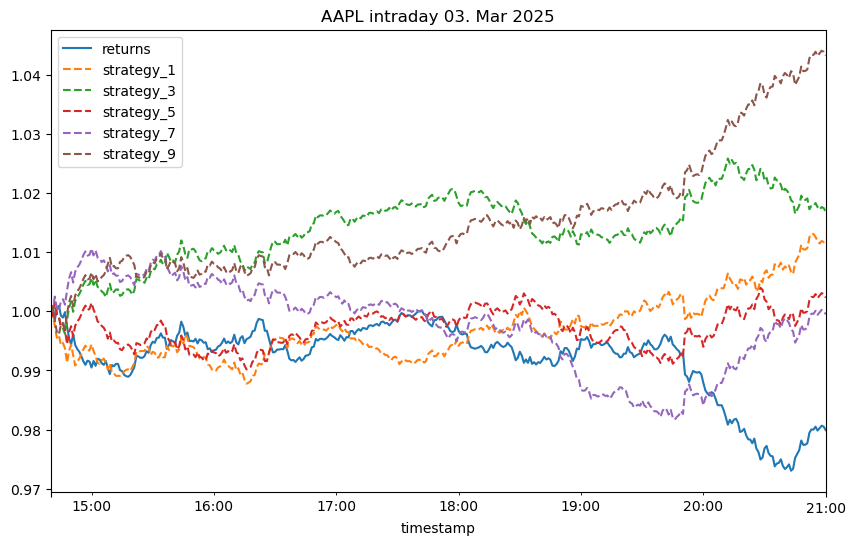

In [24]:
data[to_plot].dropna().cumsum().apply(np.exp).plot(title="AAPL intraday 03. Mar 2025", figsize=(10, 6), style=['-', '--', '--', '--', '--', '--']);

In [1]:
import MomVectorBacktester as Mom

In [2]:
mombt = Mom.MomVectorBacktester('XAU=', '2010-1-1', '2019-12-31', 10000, 0.0)

In [3]:
mombt.run_strategy(momentum=3)

(np.float64(20797.87), np.float64(7395.53))

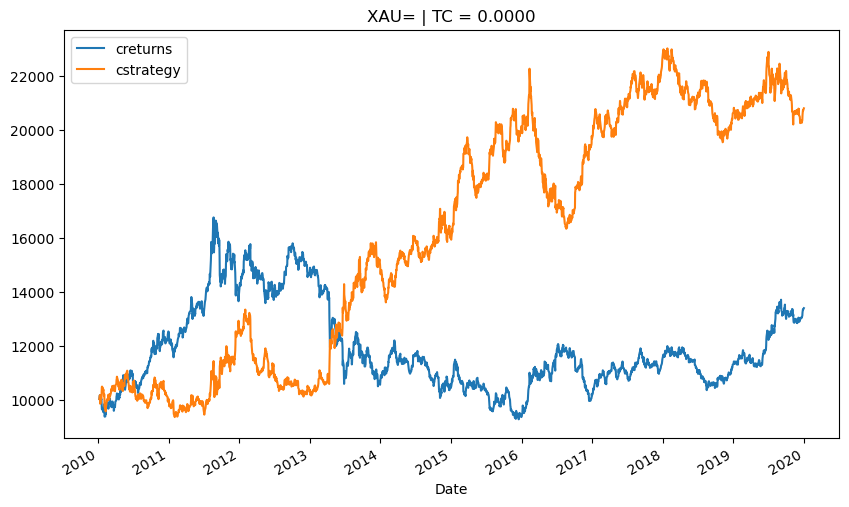

In [4]:
mombt.plot_results()

In [5]:
mombt = Mom.MomVectorBacktester('XAU=', '2010-1-1', '2019-12-31', 10000, 0.001)

In [6]:
mombt.run_strategy(momentum=3)

(np.float64(10749.4), np.float64(-2652.93))

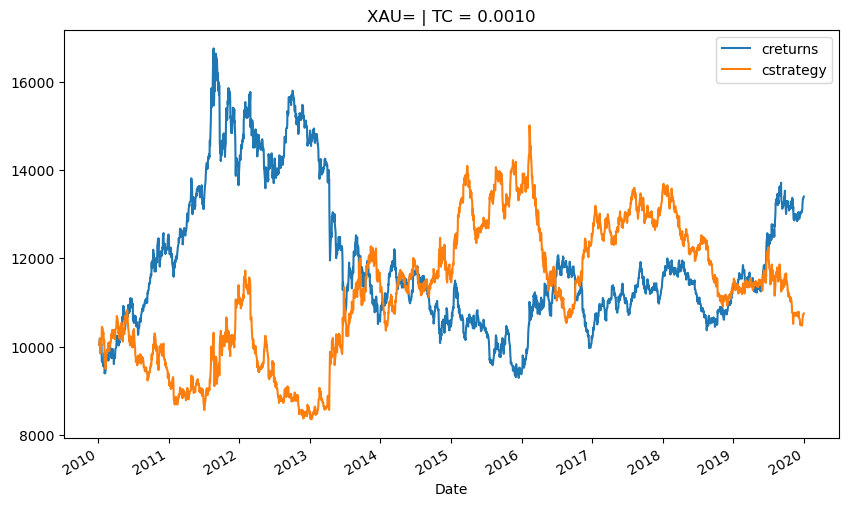

In [7]:
mombt.plot_results()